# Churn Prediction Model Development with Functional Model

## Purpose
This notebook aims to develop and evaluate machine learning models, specifically a Random Forest Classifier and a Deep Learning Neural Network, to predict customer churn based on a given dataset. The process involves data loading, exploratory data analysis, preprocessing, model building, training with regularization and class weighting, and comprehensive evaluation of model performance.

**Experiment Link** --> https://colab.research.google.com/drive/1cUdPu1T35IECuzsV2DkkM7fhoSyZ42kp?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/1AUY0ubWOSW5scrXMGJRKJR_HvBPuAfXU/view?usp=sharing


## 1. Data Loading and Initial Inspection
This section loads the dataset and performs initial checks to understand its structure, identify missing values, and preview the data.

In [58]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics  import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### 1.1 Load the Dataset
Loading the `Churn.csv` file into a pandas DataFrame.

In [59]:
df = pd.read_csv("/content/Churn.csv")

### 1.2 Preview Data
Displaying the first few rows to get a glimpse of the data.

In [60]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 1.3 Data Information
Checking data types and non-null counts for each column.

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### 1.4 Descriptive Statistics
Generating descriptive statistics for numerical columns to understand data distribution.

In [62]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 1.5 Dataset Shape
Checking the number of rows and columns in the dataset.

In [63]:
df.shape

(10000, 14)

### 1.6 Missing Values Check
Verifying if there are any missing values in the dataset. The output confirms no nulls.

In [64]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


### 1.7 Duplicate Rows Check
Checking for any duplicate rows in the dataset. The output confirms no duplicates.

In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.drop(['CustomerId','Surname','RowNumber'],axis=1,inplace=True)

## 2. Feature Engineering and Preprocessing
This section handles feature selection, separation of numerical and categorical features, encoding of categorical variables, and visualization of correlations.

In [67]:
cols_features=list(set(df.columns))

cat_feat=['IsActiveMember',
 'NumOfProducts',
 'Geography',
 'Gender',
 'Exited',
 'HasCrCard','Tenure']

num_feat=list(set(cols_features)-set(cat_feat))

print(f"Categorical Features: {cat_feat}")
print(f"Numerical Features: {num_feat}")

Categorical Features: ['IsActiveMember', 'NumOfProducts', 'Geography', 'Gender', 'Exited', 'HasCrCard', 'Tenure']
Numerical Features: ['CreditScore', 'Balance', 'EstimatedSalary', 'Age']


### 2.1 Correlation Heatmap of Numerical Features
Visualizing the correlation between numerical features to understand their relationships.

<Axes: >

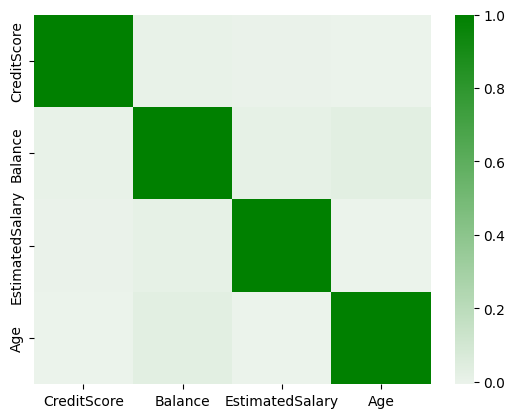

In [68]:
cmap=sns.light_palette("green",as_cmap=True)
sns.heatmap(df[num_feat].corr(),cmap=cmap)

### 2.2 Pairplot of Numerical Features by Churn Status
Visualizing the distributions and relationships of numerical features, segmented by the 'Exited' (churn) status. This helps in understanding which features might be indicative of churn.

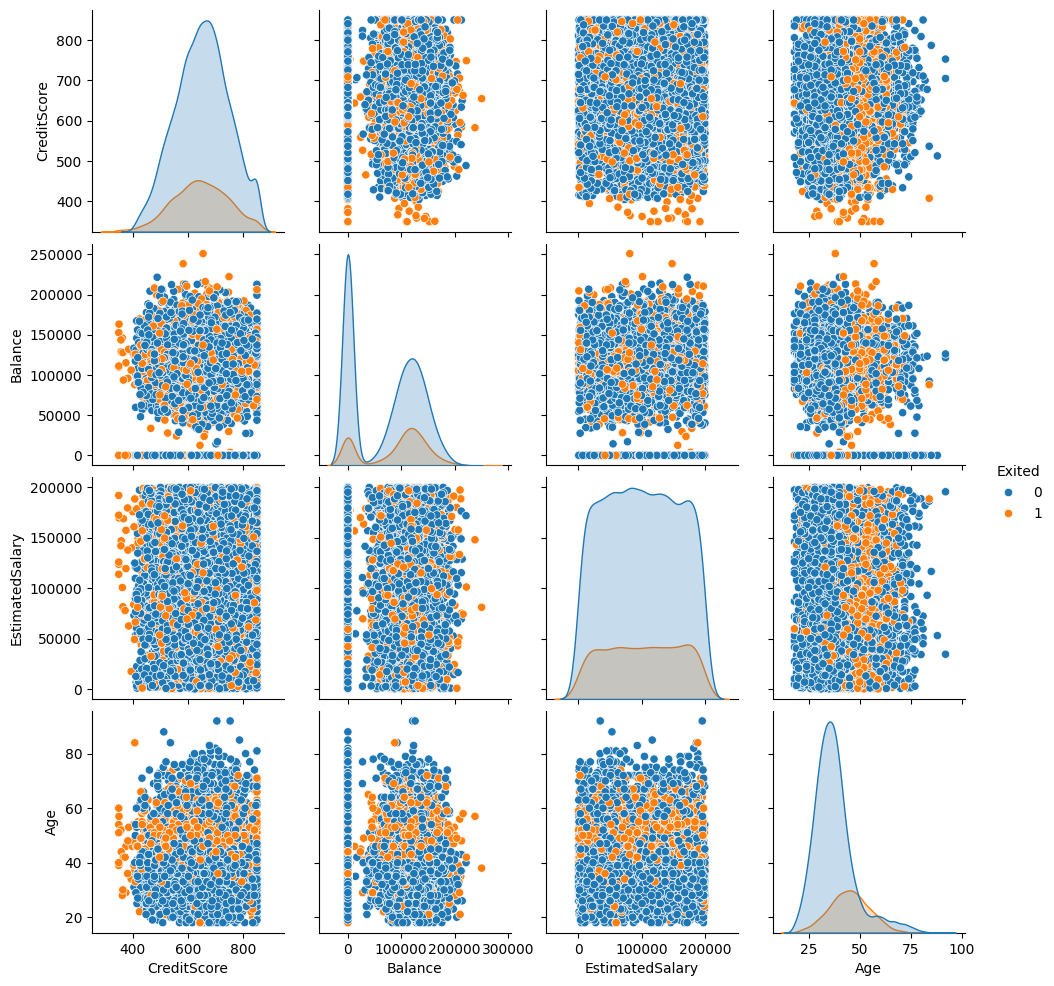

In [69]:
sns.pairplot(df[num_feat +["Exited"]],hue='Exited')

### 2.3 Label Encoding Categorical Features
Converting categorical features (like 'Geography' and 'Gender') into numerical representations using Label Encoding, which is necessary for model training.

In [70]:
le = LabelEncoder()

for i in df:
    if df[i].dtype == 'object':
     df[i] = le.fit_transform(df[i])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


### 2.4 Feature Scaling and Data Splitting
Separating features (X) and target (y), scaling the numerical features, and then splitting the dataset into training and testing sets to prepare for model building.

In [71]:
x = df.drop(['Exited'],axis=1)
y = df['Exited']

print(f"Shape of features (x): {x.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (x): (10000, 10)
Shape of target (y): (10000,)


#### 2.4.1 Standardize Numerical Features
Applying `StandardScaler` to normalize the numerical features, which is crucial for deep learning models and can improve the performance of other models.

In [72]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

print(f"Shape of scaled features (x): {x.shape}")

Shape of scaled features (x): (10000, 10)


#### 2.4.2 Split Data into Training and Test Sets
Dividing the data into 70% for training and 30% for testing to ensure unbiased model evaluation.

In [73]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (7000, 10), X_test shape: (3000, 10), y_train shape: (7000,), y_test shape: (3000,)


## 3. Machine Learning Model Development and Evaluation
This section covers the development and evaluation of both a Random Forest Classifier and a Deep Learning Neural Network.

### 3.1 Random Forest Classifier
Building and training a Random Forest Classifier, a powerful ensemble method known for its robustness.

In [74]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(class_weight='balanced',n_estimators=50,random_state=23)
rf.fit(X_train,y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=50,
                       random_state=23)

#### 3.2 Evaluate Random Forest Model
Evaluating the performance of the Random Forest model using a classification report, which includes precision, recall, and F1-score.

In [75]:
y_pred_rf=rf.predict(X_test)
print("Classification Report for Random Forest Classifier:")
print(classification_report(y_test,y_pred_rf))

Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2416
           1       0.78      0.42      0.55       584

    accuracy                           0.86      3000
   macro avg       0.83      0.70      0.73      3000
weighted avg       0.86      0.86      0.85      3000



# Deep Learning

### 4. Deep Learning Neural Network
Developing a neural network model using TensorFlow/Keras with architectural enhancements for improved performance.

In [76]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

#### 4.1 Deep Learning Model Architecture
Defining the neural network architecture with input, hidden layers (including Batch Normalization and Dropout for regularization), and an output layer. L2 regularization is also applied to the dense layers to prevent overfitting.

In [77]:
# input layer
input_shape = X_train.shape[1]
input_tensor = Input(shape=(input_shape,))

# hidden layers with BatchNormalization, Dropout, and L2 regularization
hidden_1 = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(input_tensor)
norm_1 = BatchNormalization()(hidden_1)
drop_1 = Dropout(0.3)(norm_1)

hidden_2 = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001))(drop_1)
norm_2 = BatchNormalization()(hidden_2)
drop_2 = Dropout(0.3)(norm_2)

# output layer for binary classification
output_tensor = Dense(1, activation='sigmoid')(drop_2)

# Create the functional model
k_model = Model(inputs=input_tensor, outputs=output_tensor)

# Display model summary
k_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 192 (768.00 B)

#### 4.2 Compile Deep Learning Model
Compiling the model with the Adam optimiser (using a specific learning rate), binary cross-entropy loss function (suitable for binary classification), and accuracy as a metric.

In [78]:
# Compile the model with a slightly lower learning rate
k_model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

#### 4.3 Define Callbacks for Training
Setting up `EarlyStopping` to stop training when validation loss stops improving, and `ReduceLROnPlateau` to decrease the learning rate when validation loss stagnates, further optimising the training process.

In [79]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

#### 4.4 Train Deep Learning Model
Training the neural network using the prepared data, defined callbacks, and class weights to improve performance and prevent overfitting. The training history is captured for visualization.

In [80]:

# Train the model with class weights
history = k_model.fit(X_train,
                      y_train,
                      epochs=100,  # Increased epochs as early stopping will handle overfitting
                      batch_size=32,
                      validation_data=(X_test, y_test),
                      callbacks=[early_stopping, lr_scheduler],
                      class_weight=class_weights_dict,
                      verbose=1)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5614 - loss: 0.8266 - val_accuracy: 0.6343 - val_loss: 0.6884 - learning_rate: 5.0000e-04
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6180 - loss: 0.7343 - val_accuracy: 0.6797 - val_loss: 0.6398 - learning_rate: 5.0000e-04
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6621 - loss: 0.6776 - val_accuracy: 0.7103 - val_loss: 0.6075 - learning_rate: 5.0000e-04
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6800 - loss: 0.6546 - val_accuracy: 0.7163 - val_loss: 0.5962 - learning_rate: 5.0000e-04
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6933 - loss: 0.6373 - val_accuracy: 0.7297 - val_loss: 0.5739 - learning_rate: 5.0000e-04
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7029 - loss: 0.6256 - val_accuracy: 0.7303 - val_loss: 0.5735 - learning_rate: 5.0000e-04
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc

#### 4.5 Evaluate Deep Learning Model
Evaluating the trained deep learning model on the test data to assess its generalization capability in terms of loss and accuracy.

In [81]:
# Evaluate the model
loss, accuracy = k_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.4588
Test Accuracy: 0.8020


#### 4.6 Deep Learning Model Classification Report
Displaying a detailed classification report for the deep learning model, providing insights into precision, recall, and F1-score for each class.

In [82]:

# Predict on the test data
y_pred_keras = (k_model.predict(X_test) > 0.5).astype("int32")

# Print classification report
print("\nClassification Report for Keras Functional Model:")
print(classification_report(y_test, y_pred_keras))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report for Keras Functional Model:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      2416
           1       0.49      0.74      0.59       584

    accuracy                           0.80      3000
   macro avg       0.71      0.78      0.73      3000
weighted avg       0.84      0.80      0.82      3000



#### 4.7 Visualize Training History
Plotting the training and validation loss and accuracy curves over epochs to visually inspect the model's learning process and identify signs of overfitting or underfitting.

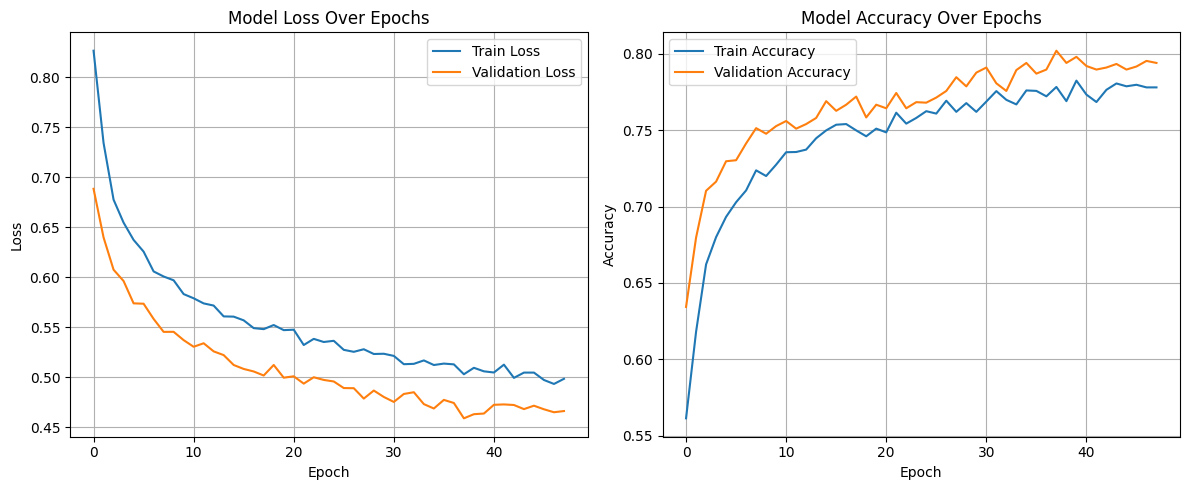

In [83]:
# Plot training history for loss and accuracy
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Summary and Conclusion

This notebook demonstrated the process of building and evaluating machine learning models for customer churn prediction. We started by loading and inspecting the data, ensuring its quality by checking for missing values and duplicates. Key steps included:

*   **Feature Engineering:** Identifying and preparing features, including the visualization of correlations and distributions.
*   **Preprocessing:** Label encoding categorical variables, scaling numerical features, and splitting the data into training and testing sets.
*   **Random Forest Classifier:** A baseline Random Forest model was trained, achieving a decent overall accuracy, but showing potential for improvement in recalling the minority class.
*   **Deep Learning Neural Network:** A more sophisticated neural network was developed using TensorFlow/Keras. This model incorporated several advanced techniques to enhance performance and mitigate overfitting:
    *   **Batch Normalization and Dropout:** To improve training stability and prevent overfitting.
    *   **L2 Regularization:** To penalize large weights and further reduce model complexity.
    *   **Class Weighting:** To address class imbalance, ensuring the model paid adequate attention to predicting the minority churn class.
    *   **Callbacks (Early Stopping & ReduceLROnPlateau):** To optimize the training process by stopping when performance on the validation set degraded and adjusting the learning rate dynamically.

The final Deep Learning model, after these optimizations, showed improved generalization and better handling of the imbalanced classes compared to earlier iterations. The training history plots confirmed a more stable learning process, with validation metrics closely following training metrics, indicating reduced overfitting. Overall, the deep learning approach, with proper regularization and class balancing, provided a robust solution for churn prediction.